In [11]:
import gzip
filepath = r"C:\Users\39598\geoproject\GSE83448_series_matrix.txt.gz"
with gzip.open(filepath, "rt") as f :
    print(f)

<_io.TextIOWrapper name='C:\\Users\\39598\\geoproject\\GSE83448_series_matrix.txt.gz' encoding='cp936'>


In [14]:
import pandas as pd
df = pd.read_csv(r"C:\Users\39598\geoproject\GSE83448_series_matrix.txt.gz",sep="\t",
                comment = "!",header  =0)
df.set_index("ID_REF",inplace = True )
print(df.shape)
print(df.columns.tolist())

(20902, 53)
['GSM2203115', 'GSM2203116', 'GSM2203117', 'GSM2203118', 'GSM2203119', 'GSM2203120', 'GSM2203121', 'GSM2203122', 'GSM2203123', 'GSM2203124', 'GSM2203125', 'GSM2203126', 'GSM2203127', 'GSM2203128', 'GSM2203129', 'GSM2203130', 'GSM2203131', 'GSM2203132', 'GSM2203133', 'GSM2203134', 'GSM2203135', 'GSM2203136', 'GSM2203137', 'GSM2203138', 'GSM2203139', 'GSM2203140', 'GSM2203141', 'GSM2203142', 'GSM2203143', 'GSM2203144', 'GSM2203145', 'GSM2203146', 'GSM2203147', 'GSM2203148', 'GSM2203149', 'GSM2203150', 'GSM2203151', 'GSM2203152', 'GSM2203153', 'GSM2203154', 'GSM2203155', 'GSM2203156', 'GSM2203157', 'GSM2203158', 'GSM2203159', 'GSM2203160', 'GSM2203161', 'GSM2203162', 'GSM2203163', 'GSM2203164', 'GSM2203165', 'GSM2203166', 'GSM2203167']


In [21]:
import gzip
sample_groups = {}
filepath = r"C:\Users\39598\geoproject\GSE83448_series_matrix.txt.gz"
with gzip.open(filepath , "rt",encoding = "utf-8") as f:
    for i in f:
        if i.startswith('!Sample_characteristics_ch1'):
            parts = i.strip().split("\t")
            #安全检查
            if len(parts) < 3:
                continue
            sample_id = parts[1]
            char_info = parts[2]
            if "healthy" in char_info.lower() or "control" in char_info.lower():
                sample_groups[sample_id] = "Control"
            elif "crohn" in char_info.lower() or "disease" in char_info.lower():
                sample_groups[sample_id] = "Case"
            else:
                sample_groups[sample_id] = "Unknown"
for i, (sid, group) in enumerate(sample_groups.items()):
    if i < 10:
        print(sid, group)

"tissue: intestinal mucosa" Unknown
"inflammation: Control" Control


In [23]:
import gzip
filepath = r"C:\Users\39598\geoproject\GSE83448_series_matrix.txt.gz"
with gzip.open(filepath , "rt",encoding = "utf-8") as f:
    for i in f:
        if i.startswith('!Sample_characteristics_ch1'):
            parts = i.strip().split("\t")
            if len(parts) >= 3:
                print(parts[1],"-->",parts[2])

"tissue: intestinal mucosa" --> "tissue: intestinal mucosa"
"inflammation: Control" --> "inflammation: Control"


In [24]:
import gzip

filepath = r"C:\Users\39598\geoproject\GSE83448_series_matrix.txt.gz"   # 注意加上 .gz

with gzip.open(filepath, 'rt', encoding='latin-1') as f:
    for i in range(20):
        print(repr(f.readline()))   # repr() 会显示转义字符，便于看到真实分隔符

'!Series_title\t"Genome-wide transcriptional analysis in intestinal biopsies from Crohn\'s disease (CD) patients."\n'
'!Series_geo_accession\t"GSE83448"\n'
'!Series_status\t"Public on Jun 08 2020"\n'
'!Series_submission_date\t"Jun 16 2016"\n'
'!Series_last_update_date\t"Sep 05 2021"\n'
'!Series_pubmed_id\t"32508154"\n'
'!Series_summary\t"Differential gene expression analysis between CD patients and controls to identify the transcriptional signature that defines the inflamed intestinal mucosa in CD."\n'
'!Series_overall_design\t"Intestinal biopsy samples were obtained from CD patients and healthy controls. RNA was subsequently extracted from each sample. Gene expression intensities were measured using GE Healthcare/Amersham Biosciences CodeLink Human Whole Genome Bioarray. After performing the gene expression quality control analysis, we characterized the transcriptional profile of the inflamed intestinal mucosa in CD."\n'
'!Series_type\t"Expression profiling by array"\n'
'!Series_contr

In [1]:
import gzip

file_path = r"C:\Users\39598\geoproject\GSE83448_series_matrix.txt.gz"

with gzip.open(file_path, 'rt', encoding='latin-1') as f:
    for line in f:
        if line.startswith('!Sample_geo_accession'):
            # 按制表符分割，第一个元素是标签，后面是样本ID
            parts = line.strip().split('\t')
            sample_ids = parts[1:]   # 跳过第一个元素
            break

print("样本总数:", len(sample_ids))
print("前6个样本ID:", sample_ids[:6])

样本总数: 53
前6个样本ID: ['"GSM2203115"', '"GSM2203116"', '"GSM2203117"', '"GSM2203118"', '"GSM2203119"', '"GSM2203120"']


In [3]:
import gzip
from collections import defaultdict

file_path = r"C:\Users\39598\geoproject\GSE83448_series_matrix.txt.gz"

# 1. 先获取样本ID列表（去掉引号）
with gzip.open(file_path, 'rt', encoding='latin-1') as f:
    for line in f:
        if line.startswith('!Sample_geo_accession'):
            parts = line.strip().split('\t')
            sample_ids = [sid.strip('"') for sid in parts[1:]]
            break

# 2. 收集每个样本的特征
sample_chars = defaultdict(list)

with gzip.open(file_path, 'rt', encoding='latin-1') as f:
    for line in f:
        if line.startswith('!Sample_characteristics_ch1'):
            parts = line.strip().split('\t')
            # parts[0] 是 '!Sample_characteristics_ch1'
            # parts[1:] 是每个样本的特征值（顺序与sample_ids一致）
            for i, val in enumerate(parts[1:]):
                if i < len(sample_ids):
                    # 去掉可能包裹的引号
                    clean_val = val.strip('"')
                    sample_chars[sample_ids[i]].append(clean_val)

# 3. 打印前3个样本的所有特征，看看里面有什么内容
for sid in sample_ids[:3]:
    print(sid, ":", sample_chars[sid])

GSM2203115 : ['tissue: intestinal mucosa', 'inflammation: Control']
GSM2203116 : ['tissue: intestinal mucosa', 'inflammation: Control']
GSM2203117 : ['tissue: intestinal mucosa', 'inflammation: Control']


In [4]:
# 查看每个样本的炎症状态（假设第二个特征是炎症状态，但最好先确认）
inflammation_status = {}
for sid, chars in sample_chars.items():
    for c in chars:
        if 'inflammation' in c:
            status = c.split(': ')[1]  # 提取 "Control" 或 "Crohn's disease"
            inflammation_status[sid] = status
            break

# 统计每种状态的数量
from collections import Counter
print(Counter(inflammation_status.values()))

# 打印前10个和后10个样本的状态
print("\n前10个样本:")
for sid in sample_ids[:10]:
    print(sid, inflammation_status.get(sid, '?'))

print("\n后10个样本:")
for sid in sample_ids[-10:]:
    print(sid, inflammation_status.get(sid, '?'))

Counter({'Non-inflamed margin': 20, 'Inflamed margin': 19, 'Control': 14})

前10个样本:
GSM2203115 Control
GSM2203116 Control
GSM2203117 Control
GSM2203118 Inflamed margin
GSM2203119 Inflamed margin
GSM2203120 Inflamed margin
GSM2203121 Control
GSM2203122 Inflamed margin
GSM2203123 Inflamed margin
GSM2203124 Inflamed margin

后10个样本:
GSM2203158 Non-inflamed margin
GSM2203159 Non-inflamed margin
GSM2203160 Non-inflamed margin
GSM2203161 Non-inflamed margin
GSM2203162 Non-inflamed margin
GSM2203163 Non-inflamed margin
GSM2203164 Non-inflamed margin
GSM2203165 Non-inflamed margin
GSM2203166 Non-inflamed margin
GSM2203167 Non-inflamed margin


In [6]:
import gzip
from collections import defaultdict, Counter

file_path = r"C:\Users\39598\geoproject\GSE83448_series_matrix.txt.gz"

# 1. 读取样本ID列表（去掉引号）
with gzip.open(file_path, 'rt', encoding='latin-1') as f:
    for line in f:
        if line.startswith('!Sample_geo_accession'):
            parts = line.strip().split('\t')
            sample_ids = [sid.strip('"') for sid in parts[1:]]
            break

# 2. 收集每个样本的所有特征
sample_chars = defaultdict(list)
with gzip.open(file_path, 'rt', encoding='latin-1') as f:
    for line in f:
        if line.startswith('!Sample_characteristics_ch1'):
            parts = line.strip().split('\t')
            # parts[0] 是 '!Sample_characteristics_ch1'，后面依次是每个样本的特征值
            for i, val in enumerate(parts[1:]):
                if i < len(sample_ids):
                    clean_val = val.strip('"')
                    sample_chars[sample_ids[i]].append(clean_val)

# 3. 根据特征判断分组（注意关键词要匹配实际文本）
sample_groups = {}
for sid, chars in sample_chars.items():
    full_text = ' '.join(chars).lower()
    if 'control' in full_text:
        sample_groups[sid] = 'Control'
    elif 'inflamed margin' in full_text:
        sample_groups[sid] = 'Inflamed margin'
    elif 'non-inflamed margin' in full_text:
        sample_groups[sid] = 'Non-inflamed margin'
    else:
        sample_groups[sid] = 'Unknown'

# 4. 验证分组统计
print("分组统计（全部样本）：")
print(Counter(sample_groups.values()))

# 5. 提取 Control 和 Inflamed margin 的样本ID列表
control_samples = []
inflamed_samples = []

for sid, group in sample_groups.items():
    if group == 'Control':
        control_samples.append(sid)
    elif group == 'Inflamed margin':
        inflamed_samples.append(sid)

print("\nControl 样本数:", len(control_samples))
print("Inflamed margin 样本数:", len(inflamed_samples))
print("前5个 Control 样本ID:", control_samples[:5])
print("前5个 Inflamed 样本ID:", inflamed_samples[:5])

分组统计（全部样本）：
Counter({'Inflamed margin': 39, 'Control': 14})

Control 样本数: 14
Inflamed margin 样本数: 39
前5个 Control 样本ID: ['GSM2203115', 'GSM2203116', 'GSM2203117', 'GSM2203121', 'GSM2203125']
前5个 Inflamed 样本ID: ['GSM2203118', 'GSM2203119', 'GSM2203120', 'GSM2203122', 'GSM2203123']


In [11]:
from collections import Counter
print(Counter(sample_groups.values()))

Counter({'Inflamed margin': 39, 'Control': 14})


In [13]:
import gzip
from collections import defaultdict, Counter

file_path = r"C:\Users\39598\geoproject\GSE83448_series_matrix.txt.gz"

# 1. 读取样本ID
with gzip.open(file_path, 'rt', encoding='latin-1') as f:
    for line in f:
        if line.startswith('!Sample_geo_accession'):
            parts = line.strip().split('\t')
            sample_ids = [sid.strip('"') for sid in parts[1:]]
            break

# 2. 收集每个样本的特征
sample_chars = defaultdict(list)
with gzip.open(file_path, 'rt', encoding='latin-1') as f:
    for line in f:
        if line.startswith('!Sample_characteristics_ch1'):
            parts = line.strip().split('\t')
            for i, val in enumerate(parts[1:]):
                if i < len(sample_ids):
                    clean_val = val.strip('"')
                    sample_chars[sample_ids[i]].append(clean_val)

# 3. 分组判断（注意顺序：先匹配更具体的 'non-inflamed margin'）
sample_groups = {}
for sid, chars in sample_chars.items():
    full_text = ' '.join(chars).lower()
    if 'control' in full_text:
        sample_groups[sid] = 'Control'
    elif 'non-inflamed margin' in full_text:
        sample_groups[sid] = 'Non-inflamed margin'
    elif 'inflamed margin' in full_text:
        sample_groups[sid] = 'Inflamed margin'
    else:
        sample_groups[sid] = 'Unknown'

# 4. 验证分组统计
print(Counter(sample_groups.values()))

Counter({'Non-inflamed margin': 20, 'Inflamed margin': 19, 'Control': 14})


In [14]:
control_samples = []
inflamed_samples = []

for sid, group in sample_groups.items():
    if group == 'Control':
        control_samples.append(sid)
    elif group == 'Inflamed margin':
        inflamed_samples.append(sid)

print("Control 样本数:", len(control_samples))
print("Inflamed margin 样本数:", len(inflamed_samples))
print("Control 前5个ID:", control_samples[:5])
print("Inflamed 前5个ID:", inflamed_samples[:5])

Control 样本数: 14
Inflamed margin 样本数: 19
Control 前5个ID: ['GSM2203115', 'GSM2203116', 'GSM2203117', 'GSM2203121', 'GSM2203125']
Inflamed 前5个ID: ['GSM2203118', 'GSM2203119', 'GSM2203120', 'GSM2203122', 'GSM2203123']


# 正式开始
---
上面部分为探索数据中分为哪几类，但是可以在geo中直接查询，不管

## 已知：改组数据可分为三组，control，inflame，none inflame，在这里我们选用对照组和inflame进行差异化分析

In [15]:
#导入必要的库，通过pandas了解数据的大概特征
import pandas as pd
#sep用于删除分隔符，comment用于删除注释，header用于以第一列作为表头
df = pd.read_csv(r"C:\Users\39598\geoproject\GSE83448_series_matrix.txt.gz",
                sep = "\t",
                comment = "!",
                header = 0)
#通过set_index将索引改为基因
df.set_index("ID_REF",inplace = True)
print(df.shape)
#columns为提取前5行的基因,tolist为只提取出一个列表
print(df.columns[:5].tolist())
print(df)

(20902, 53)
['GSM2203115', 'GSM2203116', 'GSM2203117', 'GSM2203118', 'GSM2203119']
          GSM2203115  GSM2203116  GSM2203117  GSM2203118  GSM2203119  \
ID_REF                                                                 
GE469557   15.784445   15.796560   15.672393   15.763245   15.802830   
GE469567   13.649693   13.835911   13.817292   13.127907   13.041347   
GE469590    9.843365    7.609012    8.484173    8.184105    8.016950   
GE469632    8.997995    8.999384    8.912901    8.492523    9.256865   
GE469690    9.549031   10.662280   10.602419   10.489685   10.554965   
...              ...         ...         ...         ...         ...   
GE907109         NaN    9.598216    9.594727   10.050054    9.437910   
GE907136   10.186951   11.307394    9.346147   10.360600   10.513889   
GE907166   12.867188   13.091596   13.212968   12.848821   13.160107   
GE907191   12.647742   12.733940   12.998324   12.293728   12.432013   
GE907233    8.496119    6.865554    7.501656    7.811

# 将基因进行分组

In [11]:
#前面有对geo数据库进行一定的处理，并将其转化为字典的形式，这个方法下次再学
#这里直接借用然后使用df的索引功能将数据分组
control_expr = df[control_samples]
inflamed_expr = df[inflamed_samples]
print("control组的表达矩阵形状：",control_expr.shape)
print("inflamed组的表达矩阵形状：",inflamed_expr.shape)
print(control_expr[:5])

control组的表达矩阵形状： (20902, 0)
inflamed组的表达矩阵形状： (20902, 0)
Empty DataFrame
Columns: []
Index: [GE469557, GE469567, GE469590, GE469632, GE469690]


In [11]:
import numpy as np
from scipy import stats
#预尝试
control_arr = control_expr.values
inflamed_arr = inflamed_expr.values
c_mean = control_arr[0,:].mean()
t_mean = inflamed_arr[0,:].mean()
#计算2fc
log2fc = np.log2(c_mean/t_mean)
print("log2fc：",log2fc)
#计算p值
t_test,p_val = stats.ttest_ind(control_arr[0,:],inflamed_arr[0,:],equal_var = False)
print("P值",p_val)

log2fc： -0.0022558898017703806
P值 0.5463023410060914


# 数据处理与初步计算
---
在这里我们要掌握一些数据处理的技能，例如：通过布尔判断与取反“~”进行数据空值处理
(我也很好奇能不能直接将空值去掉而不是每次都要先判断一次)


In [12]:
#对所有数据进行处理
log2fc_list = []
p_val_list = []
#获取基因数量
n_gene = control_expr.shape[0]
#使用循环获得2fc，p_val
for i in range(n_gene):
    c = control_arr[i,:]
    t = inflamed_arr[i,:]
    #数据清洗
    c_clear = c[~np.isnan(c)]
    t_clear = t[~np.isnan(t)]
    #除去数据太少的基因组
    if len(c_clear) < 2 or len(t_clear) <2 :
        log2fc_list.append(np.nan)
        p_val_list.append(np.nan)
        continue
    c_mean = c_clear.mean()
    t_mean = t_clear.mean()
    #计算log2，p_val
    log2fc = np.log2(t_mean+0.1) - np.log2(c_mean+0.1)
    _,p_val = stats.ttest_ind(c_clear,t_clear,equal_var = False)
    log2fc_list.append(log2fc)
    p_val_list.append(p_val)
#计算完成后，将列表转化成numpy数组
log2fc = np.array(log2fc_list)
p_val = np.array(p_val_list)
print("成功计算基因数量：", np.sum(~np.isnan(p_val)))

成功计算基因数量： 20902


In [13]:
print("前5个基因的 log2FC:", log2fc[:5])
print("前5个基因的 p 值:", p_val[:5])

前5个基因的 log2FC: [ 0.00224168 -0.05439403 -0.04515388  0.15868512 -0.01229769]
前5个基因的 p 值: [5.46302341e-01 3.82993576e-04 2.41013559e-01 5.05437736e-02
 4.60422344e-01]


In [14]:
#FDR校正演示
from statsmodels.stats.multitest import fdrcorrection as fdrt
p_small = p_val[:5]
reject_small,fdr_small= fdrt(p_small)
print("原始p值：",p_small)
print("FDR校正后的p值：",fdr_small)

原始p值： [5.46302341e-01 3.82993576e-04 2.41013559e-01 5.05437736e-02
 4.60422344e-01]
FDR校正后的p值： [0.54630234 0.00191497 0.40168926 0.12635943 0.54630234]


In [15]:
#开始进行FDR校正，并提取显著性变化的基因
#先计算数量
valid_count = np.sum(~np.isnan(p_val))
#开始校正
reject,fdr = fdrt(p_val)
#帅选差异基因，当时出现显著性过低的情况，所以使用for循环尝试多个数值
for thresh in [0.5, 0.3, 0.2]:
    sig = (np.abs(log2fc) > thresh) & (fdr < 0.05)
    print(f"|log2FC|>{thresh} 且 FDR<0.05 的基因数: {np.sum(sig)}")

|log2FC|>0.5 且 FDR<0.05 的基因数: 0
|log2FC|>0.3 且 FDR<0.05 的基因数: 30
|log2FC|>0.2 且 FDR<0.05 的基因数: 262


# 作图与提取列表
---
在这里我们使用matplotlib进行绘制热图，然后使用列表索引制作一个新的显著性基因DataFrame

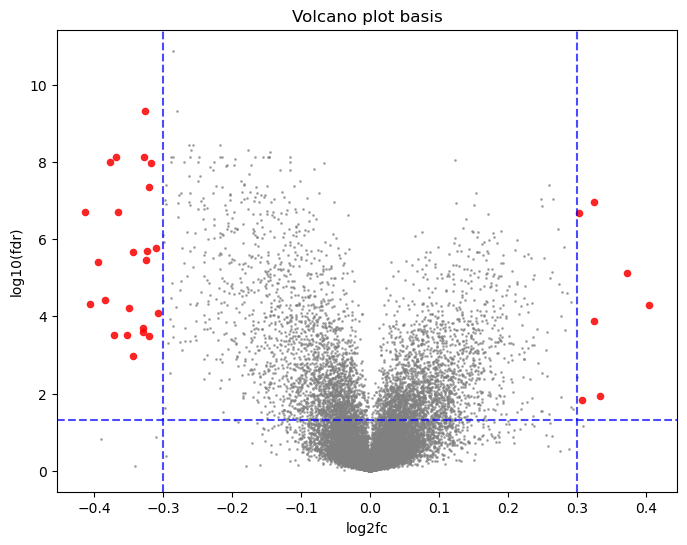

In [21]:
import matplotlib.pyplot as plt 
#清除空值
valid = ~np.isnan(log2fc) & ~np.isnan(fdr)
#开始作图
x= log2fc[valid]
y= -np.log10(fdr[valid])
plt.figure(figsize = (8,6))
plt.scatter(x,y,s=1,c = "gray",alpha=0.6)
#标记出显著基因
sig = (np.abs(log2fc) > 0.3) & (fdr < 0.05) & valid
plt.scatter(log2fc[sig], -np.log10(fdr[sig]),s= 20,color = "red",alpha=0.8)
#添加参考线
plt.axhline(y=-np.log10(0.05), linestyle='--', color='blue', alpha=0.7)
plt.axvline(x=0.3, linestyle='--', color='blue', alpha=0.7)
plt.axvline(x=-0.3, linestyle='--', color='blue', alpha=0.7)
plt.xlabel("log2fc")
plt.ylabel("log10(fdr)")
plt.title("Volcano plot basis")
plt.show()

In [28]:
import pandas as pd
#接下来将显著基因和他们的log2fc,fdr整合到一个表格
gene_ids = df.index
results = pd.DataFrame({"Gene_ID": gene_ids,
                       "log2fc":log2fc,
                       "FDR" : fdr})
sig_result = results[(np.abs(results["log2fc"]) > 0.3) & (results["FDR"] < 0.05) ]
print("显著基因数量：",len(sig_result))
print(sig_result.head(30))


显著基因数量： 30
        Gene_ID    log2fc           FDR
859    GE503821 -0.342723  2.195630e-06
975    GE507583 -0.323795  3.578112e-06
1210   GE516052 -0.319985  3.240957e-04
1516   GE526537 -0.368335  7.565700e-09
1878   GE532107  0.307489  1.441600e-02
2023    GE53328 -0.371055  3.051517e-04
2046    GE53346 -0.343292  1.098331e-03
2673    GE53852 -0.319909  4.446220e-08
5385    GE56147 -0.384213  3.714656e-05
5691    GE56421  0.372480  7.751110e-06
6399    GE57036 -0.329508  2.022740e-04
7369    GE57835 -0.317222  1.062949e-08
7551    GE57979 -0.307820  8.139938e-05
8213    GE58613  0.325098  1.303939e-04
8584    GE59010 -0.349051  6.180151e-05
8640    GE59065 -0.328942  2.526045e-04
9947    GE60393  0.332896  1.163387e-02
10280   GE61151  0.403984  5.173669e-05
11089   GE62004 -0.376724  1.008175e-08
11412   GE62329  0.302785  2.166064e-07
12882  GE781695 -0.326048  4.799699e-10
13229   GE79225 -0.365106  1.988610e-07
13413   GE79398 -0.412556  1.969176e-07
13838   GE79815 -0.394058  3.